# 01 — Prueba de concepto (histórico)

Partes 0, A y B de `microdatos.ipynb` y el intento con la priori de volumen de edificios, **con sus outputs originales**. Se conserva como registro de cómo se llegó a la espina: transporte óptimo entrópico con `prom_edad` (SRMSE 0,794 → 0,538), luego sexo (0,539) e inmigrante (0,345); la priori de volumen empeoró (0,381) y quedó descartada.

No hace falta volver a correrlo. Usa cudf (`pd` = cudf, `pand` = pandas) y lee los CSV nacionales completos. Las funciones vigentes están en el módulo `manzanas/`, y `02_espina.ipynb` (celda C0) recalcula y verifica estos mismos números.

In [1]:
import cudf as pd, numpy as np, matplotlib.pyplot as plt, json, os, geopandas as gpd, pandas as pand

In [2]:
df_personas  = pd.read_csv(os.path.join("databases","personas_censo2024.csv"), sep=";")
df_hogares   = pd.read_csv(os.path.join("databases","hogares_censo2024.csv"), sep=";")
df_viviendas = pd.read_csv(os.path.join("databases","viviendas_censo2024.csv"), sep=";")
df_manzanas  = pd.read_csv(os.path.join("databases","Base_manzana_entidad_CPV24.csv"), sep=";")

# El Problema de Transporte Óptimo Entrópico

Supongamos que nos gustaría estimar la distribución de los hombres por edad en una **comuna** que tiene **3 manzanas** y 1000 hombres.

De los datos que libera el INE tenemos:
+ Nivel macro (Comuna): Distribución por edad 
    - Jóvenes (0-17): 200
    - Adultos (18-64): 600
    - Mayores (65+): 200
+ Nivel micro (Manzana): Distribución de hombres
    - Manzana A: 500 hombres
    - Manzana B: 400 hombres
    - Manzana C: 100 hombres

Nuestro objetivo es descubrir como se cruza esta información, si lo tabulamos, nos encontramos con una matriz vacía:
| Edad / Manzana | A | B | C | Comuna |
| :-------------- | :-: | :-: | :-: | :------: |
| Jóvenes | ? | ? | ? | 200 |
| Adultos | ? | ? | ? | 600 |
| Mayores | ? | ? | ? | 200 |
| Manzana | 500 | 400 | 100 | 1000

Ahora, nuestro problema es encontrar valores para la matriz, ¿cómo lo hacemos?


## Transporte Óptimo Entrópico

Nuestro problema se vuelve a la creación de una matriz que respete las restricciones de las distribuciones marginales. Es decir, buscamos $P$ que minimice el "costo" de asignación espacial, regularizando por la entropía para suavizar la distribución.

Sea $\mu,\nu$ dos distribuciones de probabilidad y sea $C$ una matriz de costos (que tanto me cuesta mover masa de $\mu$ a $\nu$), buscamos una distribución $P$ en los couplings que minimice esta carga, es decir.

\begin{align*}
\min_{P} \quad&\sum_{i,j}P_{ij}C_{ij} - \epsilon H(P)\\ 
s.a \quad&P 1 = \mu \\ 
&P^T1 = \nu
\end{align*}
con $H(P) = -\sum_{ij}P_{ij}\log P_{ij}$.

En nuestro ejemplo:
+ $P$-Plan de transporte: la matriz vacía que queremos rellenar. Nos dirá cuántos jóvenes, adultos y mayores viven en las manzanas A, B y C.
+ $\mu$-Distribución de origen: El vector de edades de la comuna. Restricción de filas.
+ $\nu$-Distribución de destino: El vector de población del INE. Restricción de las columnas.
+ $C$-Matriz de costo: Es la lógica territorial, debe ser construida mediante información externa y por nosotros, hay que pensarlo como una penalización. En nuestro ejemplo, una manzana con mayoría de departamentos de 1-2 dormitorios podemos pensar que es menos probable que hayan jóvenes.
+ $\epsilon$-Parámetro de entropía: "Ruido", un valor mayor de este parámetro difumina más a los hombres entre manzanas.


## Pros y Contras de este modelo

+ Gracias a la regularización entrópica, el problema cuenta con solución analítica y se puede resolver de manera eficiente.
+ El problema es escalable y paralelizable.
+ No es claro que tanta privacidad entrega el parámetro $\epsilon$.
+ La matriz de costo $C$ es flexible, puede ser un pro y un contra a la vez.
+ El modelo produce distribuciones de probabilidad, por ejemplo, la solución nos puede entregar en una manzana 4.3 jóvenes y 2.7 adultos, nosotros necesitamos enteros. De todas formas, podemos muestrear con esta distribución.

# Ejercicio inicial: Comuna de Independecia

## Prueba de Concepto

Aplicamos este modelo a un caso real: **comuna de Independencia** (Región Metropolitana, CUT 13108), que tiene 470 manzanas y 116.943 personas. Trabajamos con una sola variable, **edad**, usando los mismos 7 tramos etarios que `df_manzanas` ya trae agregados por manzana (`'n_edad_0_5', n_edad_6_13', 'n_edad_14_17', 'n_edad_18_24', 'n_edad_25_44','n_edad_45_59','n_edad_60_mas'`).

Elegimos edad para esta prueba de concepto por una razón práctica: como esos 7 conteos ya existen en los datos publicados, podemos "ignorarlos" al momento de ajustar el modelo usando solo la población total por manzana (`n_per`) como restricción y compararlos al final contra el resultado reconstruido. Esto nos da un ground truth real para validar el método, sin tener que inventar uno sintético.

Concretamente, buscamos rellenar una matriz $P$ (7 tramos etarios × 470 manzanas) sujeta a dos restricciones marginales conocidas:

+ $\mu$ — **distribución de origen**: cuántas personas de la comuna caen en cada tramo etario (nivel comuna, de `df_personas`).
+ $\nu$ — **distribución de destino**: población total de cada manzana (nivel manzana, de `df_manzanas`).

Los conteos reales por tramo etario y manzana ($Y_{real}$) se guardan aparte, únicamente para la validación al final.

In [11]:
# Comuna de Independencia
COMUNA_CUT = 13108

df_personas_com = df_personas[df_personas['comuna'] == COMUNA_CUT]
df_manzanas_com = df_manzanas[df_manzanas['CUT'] == COMUNA_CUT]

df_manzanas_com['n_per'] = df_manzanas_com['n_per'].astype(int)

len(df_personas_com), len(df_manzanas_com)

(116943, 470)

In [12]:
# Definimos los conjuntos de edad:
edad_brackets = [
    ("0_5",    0,   5),
    ("6_13",   6,  13),
    ("14_17", 14,  17),
    ("18_24", 18,  24),
    ("25_44", 25,  44),
    ("45_59", 45,  59),
    ("60_mas", 60, 130),
]

edad = df_personas_com["edad"]

# Distribución de origen (comuna): conteos por tramo etario
mu = np.array([int(((edad >= low) & (edad <= high)).sum()) for _, low, high in edad_brackets])

# Distribución de destino (manzana): población total por manzana
nu = df_manzanas_com[df_manzanas_com['n_per'] > 0]['n_per'].to_numpy()

manzanas_ids = df_manzanas_com[df_manzanas_com['n_per'] > 0]["MANZENT"].to_numpy()

print("mu (por tramo etario):", dict(zip([b[0] for b in edad_brackets], mu)))
print("suma mu:", mu.sum())
print("nu (primeras 10 manzanas):", nu[:10])
print("suma nu:", nu.sum(), "| n manzanas:", len(nu))

assert mu.sum() == nu.sum() == len(df_personas_com), "Error: la suma de mu y nu no coincide con el número total de personas en la comuna."

mu (por tramo etario): {'0_5': np.int64(7554), '6_13': np.int64(11542), '14_17': np.int64(5280), '18_24': np.int64(11439), '25_44': np.int64(44178), '45_59': np.int64(19274), '60_mas': np.int64(17676)}
suma mu: 116943
nu (primeras 10 manzanas): [  9 157 189 121 124 157 113 137 131 130]
suma nu: 116943 | n manzanas: 469


In [13]:
# Guardamos la distribución real de los conteos por tramo etario y por manzana
y_real_cols = ["n_edad_0_5", "n_edad_6_13", "n_edad_14_17", "n_edad_18_24",
               "n_edad_25_44", "n_edad_45_59", "n_edad_60_mas"]
Y_real = df_manzanas_com[df_manzanas_com['n_per'] > 0][y_real_cols].to_numpy().T
Y_real = Y_real.astype(int)
Y_real.shape

(7, 469)

In [14]:
# Construcción de C
C = np.zeros((len(mu), len(nu)), dtype=int)

In [15]:
# Algoritmo de Sinkhorn para obtener la matriz de transporte óptima
from scipy.special import logsumexp
    
def sinkhorn(mu, nu, C, eps, n_iter=1000, tol=1e-9):
    """
    Resuelve el transporte óptimo entrópico entre mu (m,) y nu (n,)
    con matriz de costo C (m,n) y regularización eps.
    Devuelve P (m,n) como distribución de probabilidad conjunta (suma 1).
    """
    mu_ = mu / mu.sum()
    nu_ = nu / nu.sum()
    log_mu, log_nu = np.log(mu_), np.log(nu_)

    f = np.zeros_like(mu_, dtype=float)
    g = np.zeros_like(nu_, dtype=float)

    for _ in range(n_iter):
        f_prev = f.copy()
        f = eps * (log_mu - logsumexp((g[None, :] - C) / eps, axis=1))
        g = eps * (log_nu - logsumexp((f[:, None] - C) / eps, axis=0))
        if np.max(np.abs(f - f_prev)) < tol:
            break

    logP = (f[:, None] + g[None, :] - C) / eps
    return np.exp(logP)

In [16]:
# Calculamos la matriz de transporte óptima P usando el algoritmo de Sinkhorn
P = sinkhorn(mu, nu, C, eps=1.0, n_iter=1000)

# Pasamos a una matriz de conteos esperados 
counts = (P * mu.sum())

# Chequeo: con C=0 el resultado debe ser ~ igual al producto exterior mu_i * nu_j / N
counts_analitico = np.outer(mu, nu) / mu.sum()
print("error máx vs solución analítica:", np.abs(counts - counts_analitico).max())

# Chequeo de marginales: filas deben sumar a mu, columnas a nu
print("error marginal filas:", np.abs(counts.sum(axis=1) - mu).max())
print("error marginal columnas:", np.abs(counts.sum(axis=0) - nu).max())

error máx vs solución analítica: 6.821210263296962e-13
error marginal filas: 1.4551915228366852e-11
error marginal columnas: 1.3642420526593924e-12


In [17]:
# Baseline: error de la reconstrucción "sin costo" (C=0) vs el dato real
abs_error = np.abs(counts - Y_real)
total_abs_error = abs_error.sum()

# SRMSE (Standardized RMSE), métrica estándar en síntesis de población (Voas & Williamson, 2001)
rmse = np.sqrt(np.mean((counts - Y_real) ** 2))
srmse = rmse / np.mean(Y_real)

print("error absoluto total:", total_abs_error)
print("error absoluto promedio por celda:", abs_error.mean())
print("SRMSE (baseline, sin costo):", srmse)

error absoluto total: 30565.27802433664
error absoluto promedio por celda: 9.310166927912471
SRMSE (baseline, sin costo): 0.794002538724482


Error muy alto, esperado al repartir a las personas de forma uniforme entre las manzanas, ignorando las diferencias de ellas.

Nueva matriz $C$, para un grupo etario $i$ y una manzana $j$, definimos
$$C_{ij}= \frac{(Mean_{i}-Mean_{j})^2}{std(C)}$$

Ahora asumimos que conocemos estos promedios,

In [18]:
# Construcción de otra matriz C
prom_edad_com = (df_manzanas_com[df_manzanas_com['n_per'] > 0]["prom_edad"].astype(str).str.replace(",", ".", regex=False).astype(float).to_numpy()) # Recuperamos los valores promedio de edad por manzana
prom_edad_com = np.nan_to_num(prom_edad_com, nan=0)

edad_np = df_personas_com['edad'].to_numpy()

# Punto medio de cada tramo etario, calculado desde los datos reales
midpoints = np.array([edad_np[(edad_np >= low) & (edad_np <= high)].mean() for _, low, high in edad_brackets])
# Costo: distancia al cuadrado entre el punto medio del tramo y la edad promedio de la manzana
C = (midpoints[:, None] - prom_edad_com[None, :]) ** 2
C = C / C.std()  # normalizar escala para que eps sea comparable entre corridas

### Testeamos para varios $\epsilon$

In [19]:
for eps in [0.05, 0.1, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 5.0]:
    P = sinkhorn(mu, nu, C, eps, n_iter=20000, tol=1e-10)
    counts_c = P * mu.sum()
    row_err = np.abs(counts_c.sum(axis=1) - mu).max()
    col_err = np.abs(counts_c.sum(axis=0) - nu).max()
    rmse = np.sqrt(np.mean((counts_c - Y_real) ** 2))
    srmse = rmse / np.mean(Y_real)
    print(f"eps={eps:>5}: SRMSE={srmse:.4f} | err_fila={row_err:.4f} | err_col={col_err:.4f}")

    abs_error = np.abs(counts_c - Y_real)
    total_abs_error = abs_error.sum()

    print("error absoluto total:", total_abs_error)
    print("error absoluto promedio por celda:", abs_error.mean(),'\n')

eps= 0.05: SRMSE=2.9110 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 116367.79217353981
error absoluto promedio por celda: 35.445565694041974 

eps=  0.1: SRMSE=2.1551 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 93175.29526604943
error absoluto promedio por celda: 28.381143851979726 

eps=  0.5: SRMSE=0.7706 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 36629.82245579108
error absoluto promedio por celda: 11.157423836671057 

eps=  0.6: SRMSE=0.6780 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 31728.097719310565
error absoluto promedio por celda: 9.664361169451894 

eps=  0.7: SRMSE=0.6167 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 28083.451779618998
error absoluto promedio por celda: 8.554204014504721 

eps=  0.8: SRMSE=0.5778 | err_fila=0.0000 | err_col=0.0000
error absoluto total: 25459.53343275753
error absoluto promedio por celda: 7.754959924690079 

eps=  0.9: SRMSE=0.5548 | err_fila=0.0000 | err_col=0.0000
error absol

## Estudio del error para la nueva matriz C

In [20]:
eps_best = 1.2
P_best = sinkhorn(mu, nu, C, eps_best, n_iter=20000, tol=1e-10)
counts_best = P_best * mu.sum()
print(counts_best.shape)
counts_baseline = np.outer(mu, nu) / mu.sum()

labels = [b[0] for b in edad_brackets]

err_manzana_baseline = np.abs(counts_baseline - Y_real).sum(axis=0)  # (n_manzanas,)
err_manzana_model    = np.abs(counts_best     - Y_real).sum(axis=0)

mejora = err_manzana_baseline - err_manzana_model  # >0 = el modelo mejoró ahí

(7, 469)


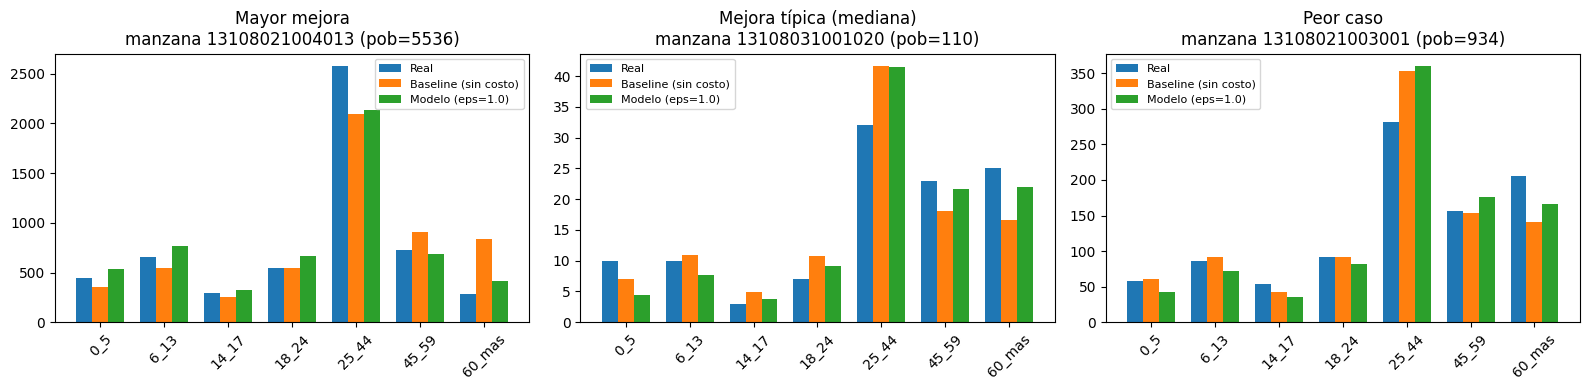

In [21]:
idx_mejor  = np.argsort(-mejora)[0]
idx_typico = np.argsort(mejora)[len(mejora) // 2]
idx_peor   = np.argsort(mejora)[0]

manzanas_a_graficar = [idx_mejor, idx_typico, idx_peor]
titulos = ["Mayor mejora", "Mejora típica (mediana)", "Peor caso"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x = np.arange(len(labels))
width = 0.25

for ax, idx, titulo in zip(axes, manzanas_a_graficar, titulos):
    ax.bar(x - width, Y_real[:, idx], width, label="Real")
    ax.bar(x, counts_baseline[:, idx], width, label="Baseline (sin costo)")
    ax.bar(x + width, counts_best[:, idx], width, label="Modelo (eps=1.0)")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.set_title(f"{titulo}\nmanzana {manzanas_ids[idx]} (pob={int(nu[idx])})")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

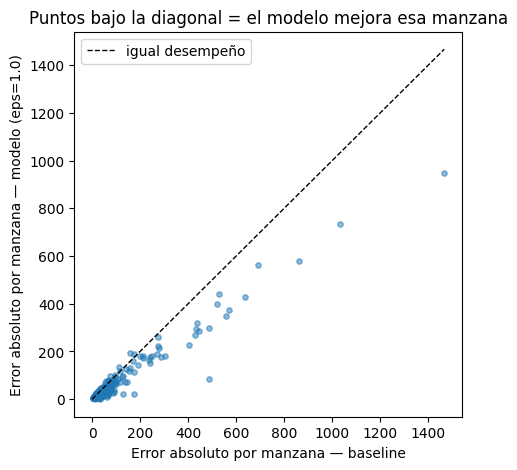

manzanas donde el modelo mejora: 379 / 469
manzanas donde el modelo empeora: 90 / 469


In [22]:
plt.figure(figsize=(5, 5))
plt.scatter(err_manzana_baseline, err_manzana_model, alpha=0.5, s=15)
lims = [0, max(err_manzana_baseline.max(), err_manzana_model.max())]
plt.plot(lims, lims, "k--", linewidth=1, label="igual desempeño")
plt.xlabel("Error absoluto por manzana — baseline")
plt.ylabel("Error absoluto por manzana — modelo (eps=1.0)")
plt.title("Puntos bajo la diagonal = el modelo mejora esa manzana")
plt.legend()
plt.show()

print(f"manzanas donde el modelo mejora: {(mejora > 0).sum()} / {len(mejora)}")
print(f"manzanas donde el modelo empeora: {(mejora < 0).sum()} / {len(mejora)}")

manzanas en el parquet para esta comuna: 577
MANZENT duplicados en mapa_comuna: 0
manzanas totales en el mapa: 577
con error asignado (parte del modelo): 468
sin dato (fuera del modelo, ej. sin población): 109


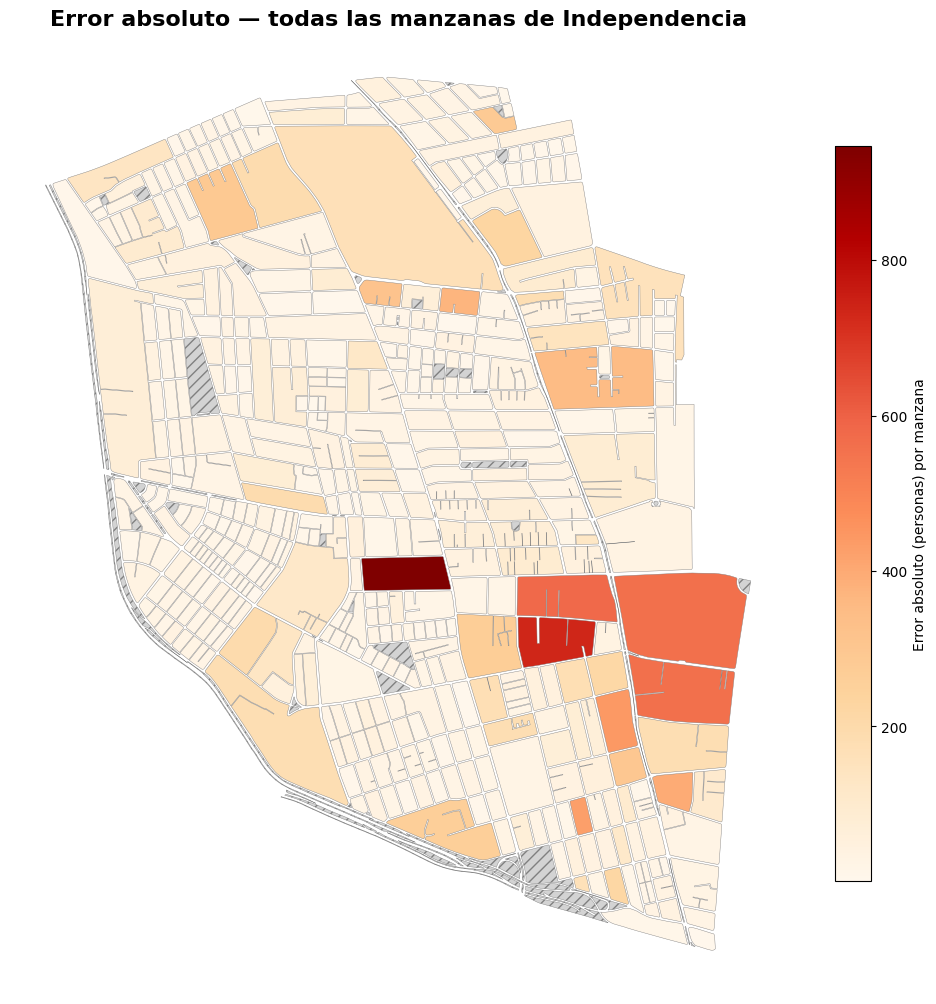

In [23]:
COMUNA_CUT = 13108
shp_path = os.path.join('cartografia_censal','Cartografia_censo2024_Pais_Manzanas.parquet')

mapa = gpd.read_parquet(shp_path)

mapa_comuna = mapa[mapa['CUT'] == COMUNA_CUT].copy()
print("manzanas en el parquet para esta comuna:", len(mapa_comuna))

mapa_comuna['MANZENT'] = mapa_comuna['MANZENT'].astype(np.int64)

# Chequeo rápido: ¿hay MANZENT duplicados? (posible si hay geometrías multi-parte)
print("MANZENT duplicados en mapa_comuna:", mapa_comuna['MANZENT'].duplicated().sum())

df_error = pand.DataFrame({
    "MANZENT": manzanas_ids,
    "absolute_error": err_manzana_model,
})

# Left merge sobre TODAS las manzanas del parquet (577), no solo las 469 del modelo
mapa_todas = mapa_comuna.merge(df_error, on='MANZENT', how='left')

print("manzanas totales en el mapa:", len(mapa_todas))
print("con error asignado (parte del modelo):", mapa_todas['absolute_error'].notna().sum())
print("sin dato (fuera del modelo, ej. sin población):", mapa_todas['absolute_error'].isna().sum())

fig, ax = plt.subplots(1, 1, figsize=(10, 15))
mapa_todas.plot(
    column='absolute_error',
    cmap='OrRd',
    linewidth=0.3,
    ax=ax,
    edgecolor='0.5',
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "0.5",
        "hatch": "///",
        "label": "Sin población / fuera del modelo",
    },
    legend_kwds={
        'label': "Error absoluto (personas) por manzana",
        'orientation': "vertical",
        'shrink': 0.5,
    },
)
ax.axis('off')
ax.set_title('Error absoluto — todas las manzanas de Independencia', fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.tight_layout()
plt.show()

In [24]:
# Tabla comparativa: población real vs predicha por manzana y tramo etario
df_comparacion = pand.DataFrame({
    "MANZENT": manzanas_ids,
    "poblacion_total": nu,
    "error_absoluto_total": err_manzana_model,
})

for i, (nombre, _, _) in enumerate(edad_brackets):
    df_comparacion[f"real_{nombre}"] = Y_real[i]
    df_comparacion[f"pred_{nombre}"] = counts_best[i].round(1)

df_comparacion = df_comparacion.sort_values("error_absoluto_total", ascending=False)
df_comparacion.head(20)

,MANZENT,poblacion_total,error_absoluto_total,real_0_5,pred_0_5,real_6_13,pred_6_13,real_14_17,pred_14_17,real_18_24,pred_18_24,real_25_44,pred_25_44,real_45_59,pred_45_59,real_60_mas,pred_60_mas
177,13108021004013,5536,946.380555,450,540.1,655,768.4,293,328.4,550,662.2,2572,2137.2,727,688.6,289,411.1
457,13108061002008,4079,733.831414,281,356.4,408,520.9,151,227.9,481,470.3,1953,1596.7,510,551.3,295,355.3
453,13108061002004,4011,578.366668,294,336.4,406,496.6,155,219.1,429,455.9,1865,1575.8,542,557.7,320,369.4
459,13108071001001,3060,560.766255,225,265.2,289,388.4,122,170.2,361,351.9,1412,1198.8,474,416.0,177,269.6
65,13108011004003,2701,441.448534,175,222.8,263,330.2,117,146.2,302,305.2,1246,1062.5,417,379.8,181,254.3
83,13108011005014,2682,427.986389,218,261.7,328,372.3,130,159.1,298,320.8,1180,1035.4,403,333.6,125,199.2
462,13108071002004,1618,399.248153,156,171.5,166,238.9,74,100.2,166,198.4,805,615.6,198,187.8,53,105.6
337,13108041002004,1933,373.738894,158,187.2,230,266.8,78,114.2,199,230.6,934,747.1,220,241.9,114,145.2
409,13108051003011,3594,349.670723,268,272.5,357,411.8,140,185.4,354,393.5,1595,1420.2,522,533.4,358,377.2
335,13108041002002,1406,317.997398,125,125.8,120,182.9,53,79.6,144,163.5,708,549.0,165,186.8,91,118.4


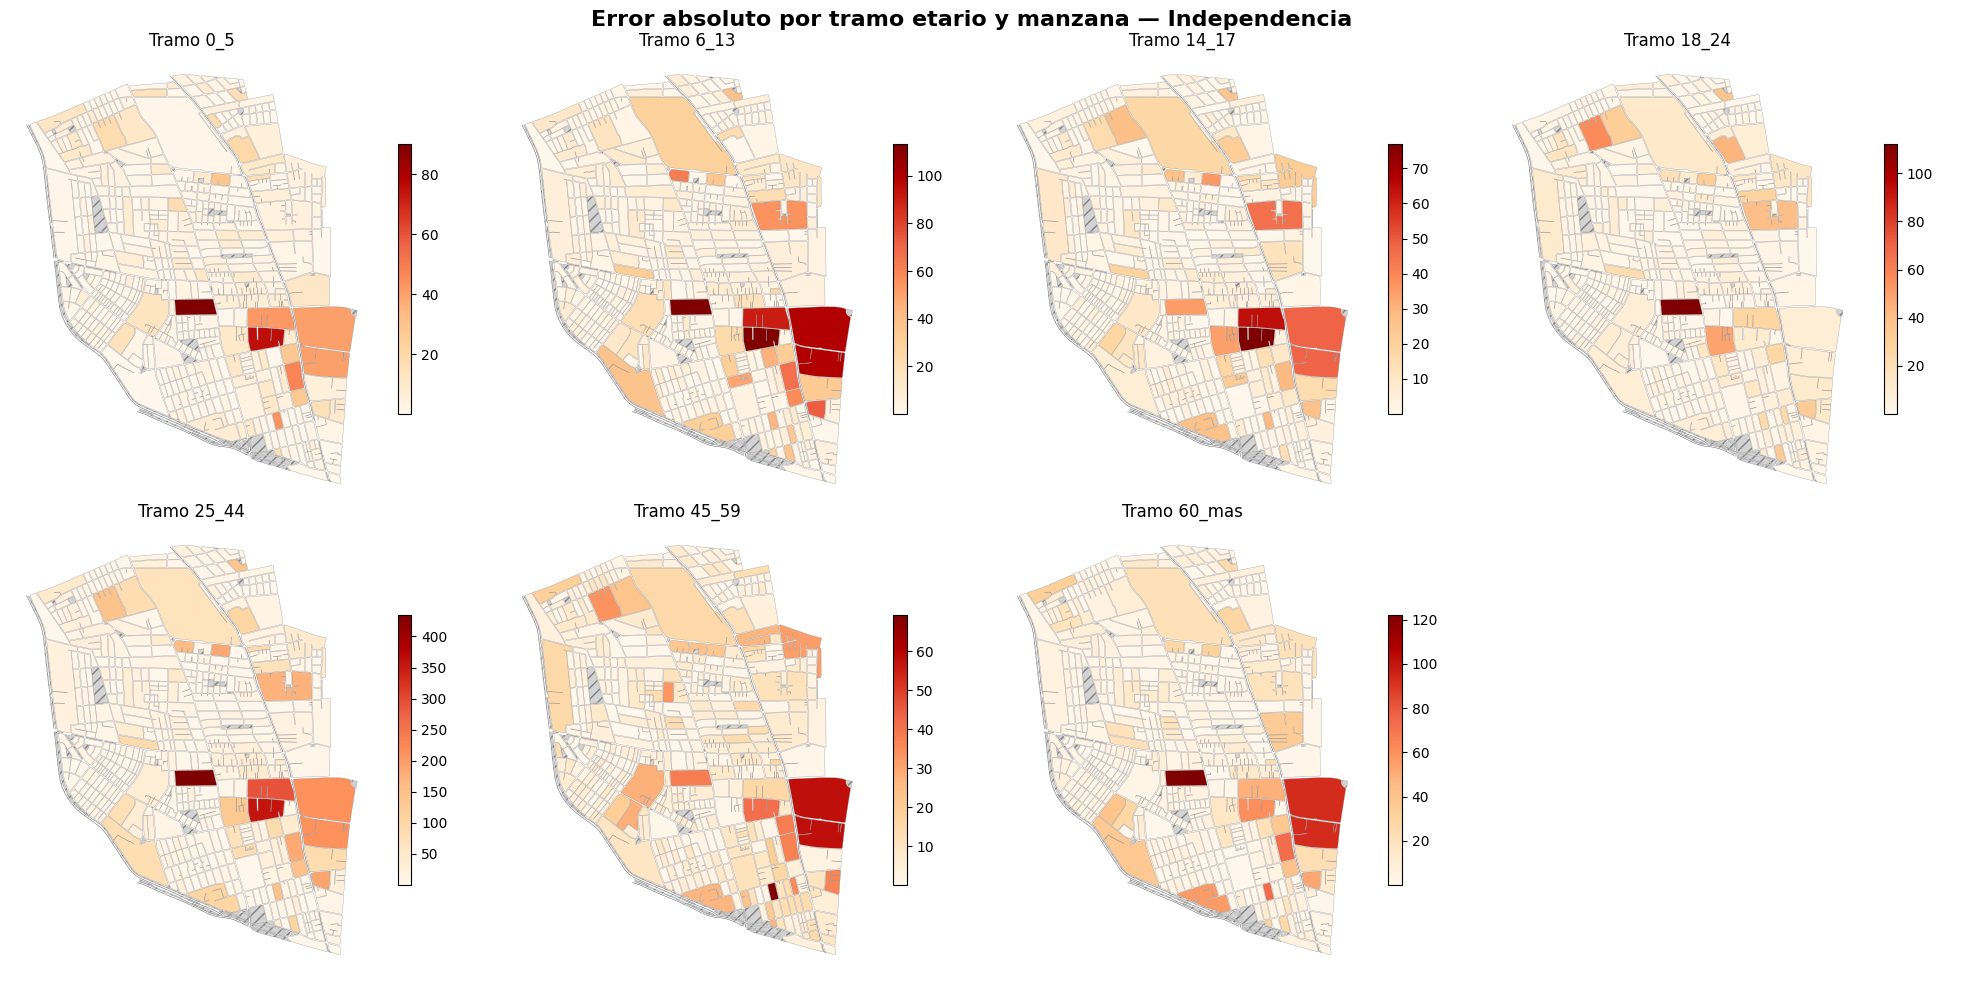

In [25]:
abs_error_bracket = np.abs(counts_best - Y_real)  # (7, n_manzanas), mismo orden que manzanas_ids

df_error_brackets = pand.DataFrame({"MANZENT": manzanas_ids})
for i, (nombre, _, _) in enumerate(edad_brackets):
    df_error_brackets[f"error_{nombre}"] = abs_error_bracket[i]

mapa_filtrado = mapa_todas.merge(df_error_brackets, on="MANZENT", how="left")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (nombre, _, _) in enumerate(edad_brackets):
    mapa_filtrado.plot(
        column=f"error_{nombre}",
        cmap='OrRd',
        linewidth=0.2,
        ax=axes[i],
        edgecolor='0.5',
        legend=True,
        legend_kwds={'shrink': 0.6},
        missing_kwds={
            "color": "lightgrey",
            "edgecolor": "0.5",
            "hatch": "///",
            "label": "Sin dato"
        }
    )
    axes[i].axis('off')
    axes[i].set_title(f"Tramo {nombre}", fontsize=12)

axes[-1].axis('off')  # sobra un subplot (7 tramos en grilla 2x4)
plt.suptitle('Error absoluto por tramo etario y manzana — Independencia', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
set_mapa = set(mapa_comuna['MANZENT'].tolist())
set_censo = set(manzanas_ids.tolist())
faltantes = set_censo - set_mapa
idx_faltantes = [i for i, m in enumerate(manzanas_ids) if m in faltantes]

print("manzanas del modelo sin geometría en el shapefile:", len(faltantes))
print(sorted(faltantes))
print()

abs_error_bracket = np.abs(counts_best - Y_real)  # (7, n_manzanas), mismo orden que manzanas_ids

for i, (nombre, _, _) in enumerate(edad_brackets):
    print(f"--- Tramo {nombre} ---")
    print("población real de esas manzanas:", Y_real[i, idx_faltantes])
    print("error absoluto de esas manzanas:", abs_error_bracket[i, idx_faltantes])
    print("% de la población del tramo que representan:", Y_real[i, idx_faltantes].sum() / Y_real[i].sum() * 100)
    print()

manzanas del modelo sin geometría en el shapefile: 1
[13108991999999]

--- Tramo 0_5 ---
población real de esas manzanas: [76]
error absoluto de esas manzanas: [15.76176114]
% de la población del tramo que representan: 1.0060894890124437

--- Tramo 6_13 ---
población real de esas manzanas: [147]
error absoluto de esas manzanas: [3.41618842]
% de la población del tramo que representan: 1.2736094264425577

--- Tramo 14_17 ---
población real de esas manzanas: [54]
error absoluto de esas manzanas: [18.73016826]
% de la población del tramo que representan: 1.0227272727272727

--- Tramo 18_24 ---
población real de esas manzanas: [177]
error absoluto de esas manzanas: [11.67704732]
% de la población del tramo que representan: 1.5473380540257016

--- Tramo 25_44 ---
población real de esas manzanas: [689]
error absoluto de esas manzanas: [5.27741522]
% de la población del tramo que representan: 1.559599800805831

--- Tramo 45_59 ---
población real de esas manzanas: [400]
error absoluto de esas 

### Asignación de manzana

Dado que la solución nos entrega un resultado (probablemente fraccional), debemos redondear para tener conteos enteros que coincidan con los conteos reales.

Para esto, usaremos el algoritmo de __Largest Remainder Round__, que toma la función piso de cada población y luego asigna las unidades vacantes a aquellos con el resto más grande.


In [27]:
def largest_remainder_round(row, total):
    """Redondea una fila de conteos continuos a enteros que sumen exactamente `total`."""
    floor_vals = np.floor(row).astype(int)
    remainder = int(total - floor_vals.sum())
    frac = row - floor_vals
    idx = np.argsort(-frac)
    floor_vals[idx[:remainder]] += 1
    return floor_vals

counts_int = np.vstack([
    largest_remainder_round(counts[i], mu[i])
    for i in range(len(mu))
])

assert (counts_int.sum(axis=1) == mu).all()
counts_int.sum()  # debería dar 116943

np.int64(116943)

Cómo le asignamos a cada persona una manzana? en este caso como tenemos la característica de edad, podemos asignar de forma aleatoria.

In [28]:
rng = np.random.default_rng(42)

df_personas_com = df_personas_com.reset_index(drop=True)  # para que la posición sea inequívoca
edad_np = df_personas_com["edad"].to_numpy()
manzana_asignada = np.empty(len(df_personas_com), dtype=manzanas_ids.dtype)

for i, (_, lo, hi) in enumerate(edad_brackets):
    idx_bracket = np.where((edad_np >= lo) & (edad_np <= hi))[0]
    rng.shuffle(idx_bracket)  # el orden dentro del tramo no debe influir en la manzana asignada

    splits = np.cumsum(counts_int[i])[:-1]
    grupos = np.split(idx_bracket, splits)  # un grupo de personas por manzana

    for j, grupo in enumerate(grupos):
        manzana_asignada[grupo] = manzanas_ids[j]

df_personas_com["manzana_asignada"] = manzana_asignada

## Generalización: Multi-Marginal (*Raking*)

El planteamiento original (transporte óptimo entrópico entre dos marginales, $\mu$ y $\nu$) es en realidad un caso particular de un problema más general: "reconciliar" varias proyecciones marginales conocidas de una tabla que nunca observamos completa. Formalizando este problema:

### Planteamiento general

Sean $X_1, \dots, X_K$ un conjunto de variables categóricas de interés (edad, sexo, condición migratoria, etc.) y $M$ la manzana. El objeto que realmente nos gustaría conocer es el tensor

$$
T[x_1, \dots, x_K, m] = \#\{\text{personas con } X_1=x_1,\dots,X_K=x_K \text{ que viven en la manzana } m\}
$$

nosotros **NO** concemos esta información (no es pública completo) y es precisamente lo que estamos tratando de reconstruir.

Lo que sí tenemos son proyecciones parciales de $T$:

- **A nivel comuna**, la conjunta completa de cualquier subconjunto de variables (porque tenemos el microdato persona a persona):
$$
\mu[x_1,\dots,x_K] = \sum_{m} T[x_1,\dots,x_K,m]
$$
- **A nivel manzana**, solo proyecciones univariadas (nunca cruces) para las variables que el INE decide agregar y publicar:
$$
\nu^{(k)}[x_k, m] = \sum_{x_1,\dots,\widehat{x_k},\dots,x_K} T[x_1,\dots,x_K,m]
$$

### El problema de reconciliación

Dado un conjunto de $J$ restricciones marginales conocidas (restricciones de población) $\{(S_j, M_j)\}_{j=1}^{J}$ — donde $S_j$ son los ejes que sí se mantienen y $M_j$ el valor conocido de esa proyección — buscamos el tensor $T$ más cercano (en divergencia KL) a una semilla/prior $T^{(0)}$ que sea consistente con **todas** las restricciones a la vez:

$$
T^* = \arg\min_{T \geq 0} \ D_{KL}\!\left(T \,\|\, T^{(0)}\right) \quad \text{s.a.} \quad \sum_{\text{ejes} \notin S_j} T = M_j \quad \forall j
$$

Esto se resuelve con **Iterative Proportional Fitting (IPF / raking)**: se alterna, restricción por restricción, un reescalado multiplicativo

$$
T^{(t+1)} \leftarrow T^{(t)} \cdot \frac{M_j}{\operatorname{proj}_{S_j}\!\left(T^{(t)}\right)}
$$

hasta que $T$ deja de cambiar. Cuando alguna celda de $M_j$ es desconocida (enmascarada por secreto estadístico), simplemente se omite esa celda del reescalado (no se fuerza el ajuste).

### Equivalencia con el modelo de transporte óptimo entrópico

Con exactamente **2** restricciones (una "fila" $\mu$, una "columna" $\nu$) y semilla $T^{(0)}_{ij} = e^{-C_{ij}/\epsilon}$, este problema es matemáticamente idéntico al transporte óptimo entrópico — Sinkhorn es IPF con esa semilla particular. Todo el desarrollo inicial (comuna de Independencia, edad, costo con `prom_edad`) es el caso $J=2$ de este marco.

### Cómo se agrega cada variable nueva

Al incorporar una variable $X_k$ adicional:

1. **$\mu$ se extiende** incluyendo $X_k$ en la conjunta comunal — siempre posible, ya que a nivel comuna tenemos el microdato completo.
2. **Se agrega una restricción nueva** $(S_k, \nu^{(k)})$, solo si esa variable existe agregada a nivel manzana.
3. **La semilla se hereda del paso anterior**: $T^{(0)}_{\text{nuevo}} = T^{*}_{\text{anterior}} \times (\text{reparto según la mejor info disponible de } X_k)$ — la proporción real por manzana si el dato existe, o la tasa global de la comuna si está suprimido.

Este es exactamente el patrón que seguimos: **edad** ($J=2$) → **+ sexo** (una restricción más, semilla = resultado de edad repartido por sexo real) → **+ condición migratoria** (otra restricción más, semilla = resultado anterior repartido por tasa migratoria, con celdas sin restricción donde el INE enmascaró el dato). Agregar una variable $K{+}1$-ésima no cambia la estructura del problema — solo se suma una fila a la lista de restricciones.

## Parte A -- Sexo como segunda variable

### A1. Marginales: conjunta comuna (μ) y sexo por manzana (ν)

In [29]:
sexo_np = df_personas_com["sexo"].to_numpy()  # 1=hombre, 2=mujer
edad_np = df_personas_com["edad"].to_numpy()

mu_edad_sexo = np.zeros((len(edad_brackets), 2), dtype=int)
for i, (_, lo, hi) in enumerate(edad_brackets):
    for s in [1, 2]:
        mu_edad_sexo[i, s - 1] = int(((edad_np >= lo) & (edad_np <= hi) & (sexo_np == s)).sum())

nu_sexo = np.vstack([
    df_manzanas_com[df_manzanas_com['n_per'] > 0]["n_hombres"].to_numpy(),
    df_manzanas_com[df_manzanas_com['n_per'] > 0]["n_mujeres"].to_numpy(),
]).astype(int)  # (2, 469)

assert mu_edad_sexo.sum() == nu_sexo.sum() == len(df_personas_com)
print("total hombres (comuna):", mu_edad_sexo[:, 0].sum(), "| (manzanas):", nu_sexo[0].sum())
print("total mujeres (comuna):", mu_edad_sexo[:, 1].sum(), "| (manzanas):", nu_sexo[1].sum())

total hombres (comuna): 56916 | (manzanas): 56916
total mujeres (comuna): 60027 | (manzanas): 60027


Ambos totales calzan exacto (116.943). 

### A2. Primera versión de raking

In [30]:
def ipf_edad_sexo_manzana(mu_edad_sexo, nu_sexo, n_iter=200, tol=1e-10, seed=None):
    """Reconcilia T[edad,sexo,manzana] con sum_manzana T[e,s,:]==mu_edad_sexo[e,s]
    y sum_edad T[:,s,m]==nu_sexo[s,m]."""
    n_edad, n_sexo = mu_edad_sexo.shape
    n_manzana = nu_sexo.shape[1]
    T = np.ones((n_edad, n_sexo, n_manzana)) if seed is None else seed.copy()

    for it in range(n_iter):
        T_prev = T.copy()
        current = T.sum(axis=2)
        factor = np.divide(mu_edad_sexo, current, out=np.zeros_like(current, dtype=float), where=current > 0)
        T = T * factor[:, :, None]
        current = T.sum(axis=0)
        factor = np.divide(nu_sexo, current, out=np.zeros_like(current, dtype=float), where=current > 0)
        T = T * factor[None, :, :]
        if np.max(np.abs(T - T_prev)) < tol:
            break
    return T, it

In [31]:
T, n_it = ipf_edad_sexo_manzana(mu_edad_sexo, nu_sexo, n_iter=500, tol=1e-10)
print("iteraciones hasta converger:", n_it)
print("error marginal (edad,sexo):", np.abs(T.sum(axis=2) - mu_edad_sexo).max())
print("error marginal (sexo,manzana):", np.abs(T.sum(axis=0) - nu_sexo).max())

iteraciones hasta converger: 1
error marginal (edad,sexo): 9.094947017729282e-13
error marginal (sexo,manzana): 4.547473508864641e-13


### A3. Semilla informada — reutiliza el resultado con costo de prom_edad de la Parte 0

In [32]:
prop_sexo_manzana = nu_sexo / nu_sexo.sum(axis=0, keepdims=True)
seed = counts_best[:, None, :] * prop_sexo_manzana[None, :, :]

In [33]:
T_informado, n_it = ipf_edad_sexo_manzana(mu_edad_sexo, nu_sexo, n_iter=500, tol=1e-10, seed=seed)
print("iteraciones:", n_it)
print("error marginal (edad,sexo):", np.abs(T_informado.sum(axis=2) - mu_edad_sexo).max())
print("error marginal (sexo,manzana):", np.abs(T_informado.sum(axis=0) - nu_sexo).max())

iteraciones: 12
error marginal (edad,sexo): 3.637978807091713e-11
error marginal (sexo,manzana): 4.547473508864641e-13


In [34]:
counts_edad_from_informado = T_informado.sum(axis=1)
srmse = np.sqrt(np.mean((counts_edad_from_informado - Y_real) ** 2)) / np.mean(Y_real)
print(srmse)

0.5393241415031332


0.5393 -- prácticamente igual al 0.5382 de antes de agregar sexo

### A4. Generalización a N restricciones — reemplaza a ipf_edad_sexo_manzana

In [35]:
def _reshape_to_broadcast(target, axes, ndim):
    shape = [1] * ndim
    dims = [d for d in range(ndim) if d not in axes]
    for dim, size in zip(dims, target.shape):
        shape[dim] = size
    return target.reshape(shape)

def ipf(seed, constraints, n_iter=500, tol=1e-10):
    T = seed.astype(float).copy()
    ndim = T.ndim
    reshaped = [(axes, _reshape_to_broadcast(t, axes, ndim)) for axes, t in constraints]
    for it in range(n_iter):
        T_prev = T.copy()
        for axes, target in reshaped:
            current = T.sum(axis=axes, keepdims=True)
            factor = np.divide(target, current, out=np.ones_like(current), where=current > 0)
            T = T * factor
        if np.max(np.abs(T - T_prev)) < tol:
            break
    return T, it

In [36]:
constraints = [((2,), mu_edad_sexo), ((0,), nu_sexo)]
T_generico, n_it = ipf(seed, constraints, n_iter=500, tol=1e-10)
print("diferencia vs la versión anterior:", np.abs(T_generico - T_informado).max())  # dio 0.0

diferencia vs la versión anterior: 0.0


## Parte B: Número de inmigrantes como tercera variable

### B1. Variable de persona equivalente a n_inmigrantes



In [37]:
nacio_chile_np = df_personas_com["p25_lug_nacimiento_rec"].to_numpy()
es_inmigrante = (nacio_chile_np == 2).astype(int)

print("inmigrantes en la comuna (de df_personas_com):", es_inmigrante.sum())
print("no respuesta:", (nacio_chile_np == -99).sum(),
      f"({(nacio_chile_np == -99).sum()/len(nacio_chile_np)*100:.2f}%)")

inmigrantes en la comuna (de df_personas_com): 51908
no respuesta: 763 (0.65%)


### B2. Secreto estadístico: '*' en n_inmigrantes de 45 manzanas

In [38]:
raw_inmigrantes = df_manzanas_com[df_manzanas_com['n_per'] > 0]["n_inmigrantes"].astype(str)
mask_enmascarada = (raw_inmigrantes == '*').to_numpy()
print("manzanas con n_inmigrantes enmascarado:", mask_enmascarada.sum(), "/", len(mask_enmascarada))

n_inmigrantes_manzana = pand.to_numeric(raw_inmigrantes.to_pandas(), errors='coerce').to_numpy()

total_inmigrantes_comuna = int(es_inmigrante.sum())
total_conocido = np.nansum(n_inmigrantes_manzana)
residual = total_inmigrantes_comuna - total_conocido

print(f"total inmigrantes comuna: {total_inmigrantes_comuna}")
print(f"suma en manzanas no enmascaradas: {total_conocido}")
print(f"residuo a repartir en las {mask_enmascarada.sum()} manzanas enmascaradas: {residual}")
print(f"promedio por manzana enmascarada: {residual / mask_enmascarada.sum():.2f}")

manzanas con n_inmigrantes enmascarado: 45 / 469
total inmigrantes comuna: 51908
suma en manzanas no enmascaradas: 51810.0
residuo a repartir en las 45 manzanas enmascaradas: 98.0
promedio por manzana enmascarada: 2.18


In [39]:
nu_inmigrante = np.vstack([
    n_inmigrantes_manzana,
    nu - n_inmigrantes_manzana,
])

print("manzanas con NaN en nu_inmigrante:", np.isnan(nu_inmigrante[0]).sum())
print("total inmigrantes (manzanas, ignorando NaN):", np.nansum(nu_inmigrante[0]),
      "| total inmigrantes (comuna, de mu):", es_inmigrante.sum())

manzanas con NaN en nu_inmigrante: 45
total inmigrantes (manzanas, ignorando NaN): 51810.0 | total inmigrantes (comuna, de mu): 51908


### B3. ipf extendida — tolera NaN (sin restricción) y reporta si convergió

In [40]:
def ipf(seed, constraints, n_iter=500, tol=1e-10):
    T = seed.astype(float).copy()
    ndim = T.ndim
    reshaped = [(axes, _reshape_to_broadcast(t, axes, ndim)) for axes, t in constraints]
    for it in range(n_iter):
        T_prev = T.copy()
        for axes, target in reshaped:
            current = T.sum(axis=axes, keepdims=True)
            ratio = np.divide(target, current, out=np.ones_like(current), where=current > 0)
            factor = np.where(np.isnan(target), 1.0, ratio)  # NaN = sin restricción, deja la semilla intacta ahí
            T = T * factor
        delta = np.max(np.abs(T - T_prev))
        if delta < tol:
            return T, it, True
    return T, n_iter, False

### B4. Conjunta comuna de 3 variables

In [41]:
mu_edad_sexo_inmigrante = np.zeros((len(edad_brackets), 2, 2), dtype=int)  # último eje: [inmigrante, no_inmigrante]
for i, (_, lo, hi) in enumerate(edad_brackets):
    for s in [1, 2]:
        base = (edad_np >= lo) & (edad_np <= hi) & (sexo_np == s)
        mu_edad_sexo_inmigrante[i, s - 1, 0] = int((base & (es_inmigrante == 1)).sum())
        mu_edad_sexo_inmigrante[i, s - 1, 1] = int((base & (es_inmigrante == 0)).sum())

assert mu_edad_sexo_inmigrante.sum() == len(df_personas_com)

### B5. Semilla 4D y primera corrida (insuficiente)



In [42]:
tasa_inmigrante_comuna = es_inmigrante.mean()
prop_inmigrante = np.array([tasa_inmigrante_comuna, 1 - tasa_inmigrante_comuna])
seed_4d = T_informado[:, :, None, :] * prop_inmigrante[None, None, :, None]

constraints_4d = [
    ((3,),   mu_edad_sexo_inmigrante),
    ((0, 2), nu_sexo),
    ((0, 1), nu_inmigrante),
]

T_4d, n_it, convergence = ipf(seed_4d, constraints_4d, n_iter=1000, tol=1e-10)
print("iteraciones:", n_it)
print("error marginal (edad,sexo,inmigrante):", np.abs(T_4d.sum(axis=3) - mu_edad_sexo_inmigrante).max())
print("error marginal (sexo,manzana):", np.abs(T_4d.sum(axis=(0, 2)) - nu_sexo).max())

check_inmigrante = T_4d.sum(axis=(0, 1))
print("error marginal inmigrante (solo manzanas NO enmascaradas):",
      np.abs(check_inmigrante[:, ~mask_enmascarada] - nu_inmigrante[:, ~mask_enmascarada]).max())

iteraciones: 1000
error marginal (edad,sexo,inmigrante): 1.0192597790992295
error marginal (sexo,manzana): 0.0018839348831534153
error marginal inmigrante (solo manzanas NO enmascaradas): 9.094947017729282e-13


### B6 — corrida final (50.000 iter, converge)

In [43]:
T_4d, n_it, convergio = ipf(seed_4d, constraints_4d, n_iter=50000, tol=1e-10)
print("iteraciones:", n_it, "| convergió:", convergio)
print("error marginal (edad,sexo,inmigrante):", np.abs(T_4d.sum(axis=3) - mu_edad_sexo_inmigrante).max())
print("error marginal (sexo,manzana):", np.abs(T_4d.sum(axis=(0, 2)) - nu_sexo).max())

check_inmigrante = T_4d.sum(axis=(0, 1))
print("error marginal inmigrante (no enmascaradas):",
      np.abs(check_inmigrante[:, ~mask_enmascarada] - nu_inmigrante[:, ~mask_enmascarada]).max())

iteraciones: 5354 | convergió: True
error marginal (edad,sexo,inmigrante): 6.432364898500964e-07
error marginal (sexo,manzana): 1.1896190699189901e-09
error marginal inmigrante (no enmascaradas): 1.3642420526593924e-12


### B7 — SRMSE final (con etiqueta descriptiva)

In [44]:
counts_edad_from_4d = T_4d.sum(axis=(1, 2))
rmse = np.sqrt(np.mean((counts_edad_from_4d - Y_real) ** 2))
srmse = rmse / np.mean(Y_real)
print("SRMSE de la marginal de edad implícita (con sexo e inmigrante incorporados):", srmse)

SRMSE de la marginal de edad implícita (con sexo e inmigrante incorporados): 0.34516508223838843


In [45]:
# Error espacial del modelo de 2 variables (edad + sexo) -- colapsa sexo y compara contra Y_real
counts_edad_2var = T_informado.sum(axis=1)  # (edad, manzana)
err_manzana_2var = np.abs(counts_edad_2var - Y_real).sum(axis=0)  # (manzana,)

# Error espacial del modelo de 3 variables (edad + sexo + inmigrante)
counts_edad_3var = T_4d.sum(axis=(1, 2))  # (edad, manzana)
err_manzana_3var = np.abs(counts_edad_3var - Y_real).sum(axis=0)  # (manzana,)

print("error total 2 variables:", err_manzana_2var.sum())
print("error total 3 variables:", err_manzana_3var.sum())

error total 2 variables: 21855.35942230361
error total 3 variables: 17281.91074913842


In [46]:
df_error_comparacion = pand.DataFrame({
    "MANZENT": manzanas_ids,
    "error_2var": err_manzana_2var,
    "error_3var": err_manzana_3var,
})

mapa_comparacion = mapa_comuna[mapa_comuna['MANZENT'].isin(manzanas_ids)].copy()
mapa_comparacion = mapa_comparacion.merge(df_error_comparacion, on='MANZENT', how='left')
print("manzanas sin error asignado:", mapa_comparacion['error_2var'].isna().sum())

manzanas sin error asignado: 0


In [47]:
df_error_comparacion = pand.DataFrame({
    "MANZENT": manzanas_ids,
    "error_2var": err_manzana_2var,
    "error_3var": err_manzana_3var,
})

mapa_comparacion = mapa_comuna
mapa_comparacion = mapa_comparacion.merge(df_error_comparacion, on='MANZENT', how='left')
print("manzanas sin error asignado:", mapa_comparacion['error_2var'].isna().sum())

manzanas sin error asignado: 109


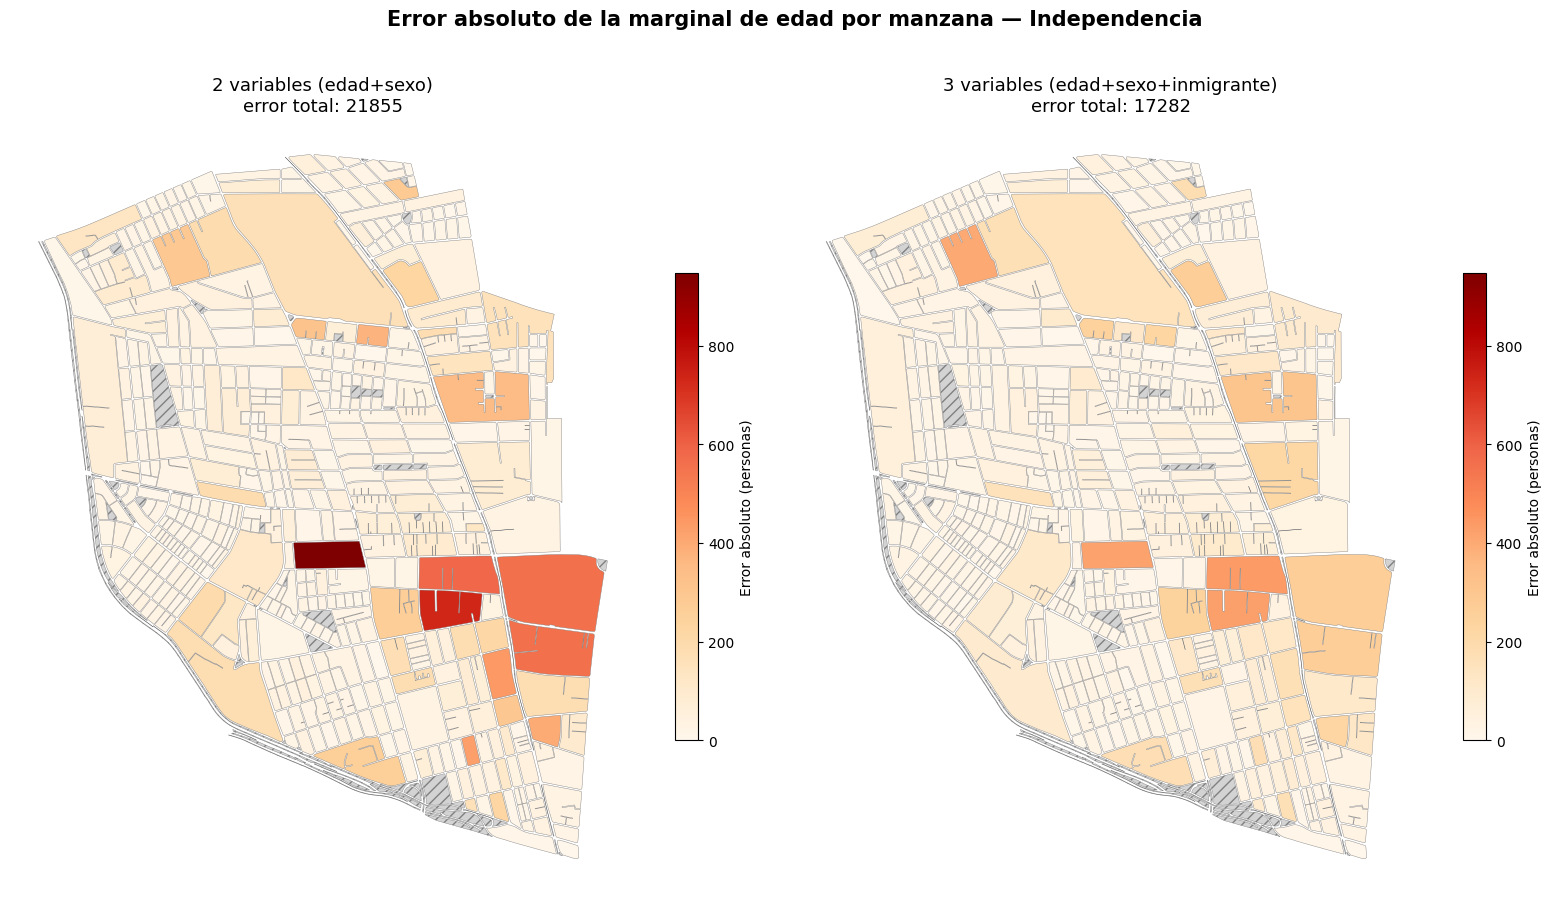

In [48]:
vmax_comun = max(mapa_comparacion['error_2var'].max(), mapa_comparacion['error_3var'].max())

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

mapa_comparacion.plot(
    column='error_2var', cmap='OrRd', linewidth=0.3, ax=axes[0], edgecolor='0.5',
    vmin=0, vmax=vmax_comun, legend=True,
    legend_kwds={'label': "Error absoluto (personas)", 'shrink': 0.5},
    missing_kwds={
                "color": "lightgrey",
                "edgecolor": "0.5",
                "hatch": "///",
                "label": "Sin dato"
            }
)
axes[0].set_title(f"2 variables (edad+sexo)\nerror total: {err_manzana_2var.sum():.0f}", fontsize=13)
axes[0].axis('off')

mapa_comparacion.plot(
    column='error_3var', cmap='OrRd', linewidth=0.3, ax=axes[1], edgecolor='0.5',
    vmin=0, vmax=vmax_comun, legend=True,
    legend_kwds={'label': "Error absoluto (personas)", 'shrink': 0.5, }, 
    missing_kwds={
                "color": "lightgrey",
                "edgecolor": "0.5",
                "hatch": "///",
                "label": "Sin dato"
            }
)

axes[1].set_title(f"3 variables (edad+sexo+inmigrante)\nerror total: {err_manzana_3var.sum():.0f}", fontsize=13)
axes[1].axis('off')

plt.suptitle("Error absoluto de la marginal de edad por manzana — Independencia", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

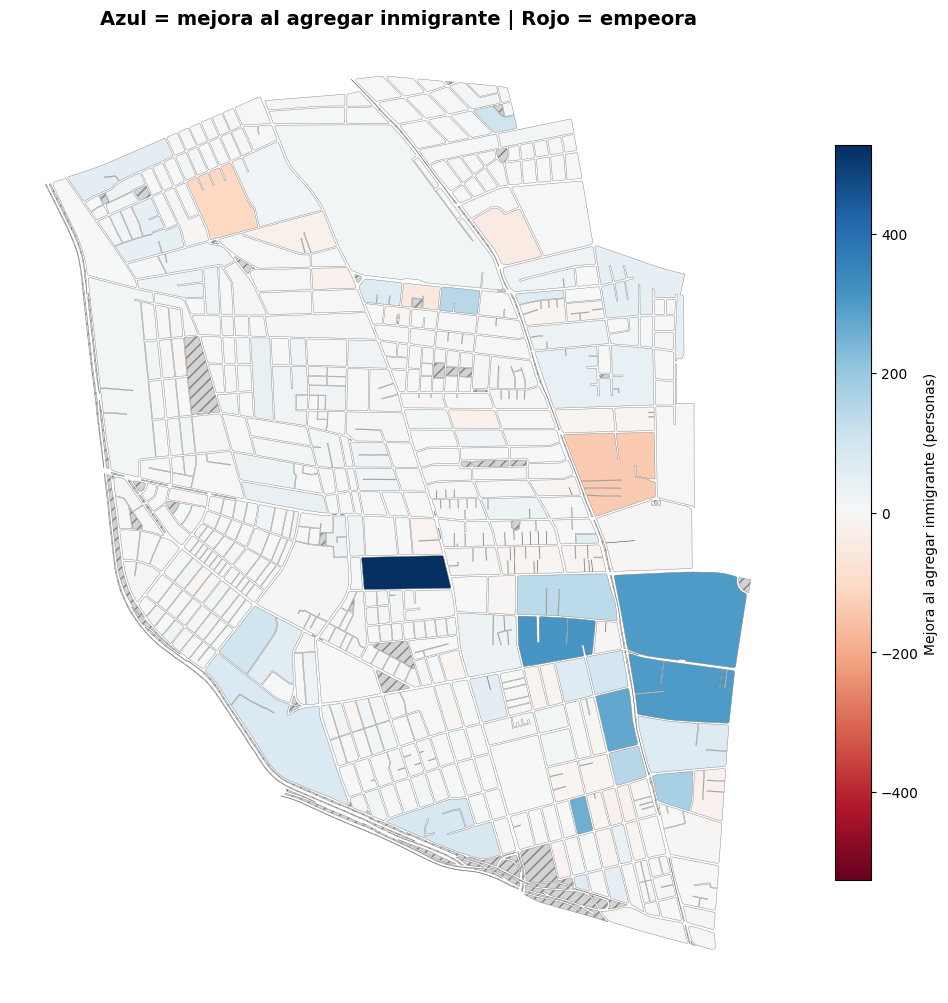

In [49]:
mapa_comparacion['mejora_3vs2'] = mapa_comparacion['error_2var'] - mapa_comparacion['error_3var']
max_abs = mapa_comparacion['mejora_3vs2'].abs().max()

fig, ax = plt.subplots(1, 1, figsize=(10, 15))
mapa_comparacion.plot(
    column='mejora_3vs2', cmap='RdBu', linewidth=0.3, ax=ax, edgecolor='0.5',
    vmin=-max_abs, vmax=max_abs, legend=True,
    legend_kwds={'label': "Mejora al agregar inmigrante (personas)", 'shrink': 0.5},
    missing_kwds={
                "color": "lightgrey",
                "edgecolor": "0.5",
                "hatch": "///",
                "label": "Sin dato"
            }
)
ax.set_title("Azul = mejora al agregar inmigrante | Rojo = empeora", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

# Usando priori con geodatos open source

In [50]:
manzanas_weights = gpd.read_parquet("priori/manzanas_weights.parquet")


In [51]:
manzanas_weights['weight'] / manzanas_weights['weight'].sum() * mu.sum()

0        0.000000
1      156.350473
2        0.000000
3      260.539356
4       89.382202
          ...    
564     39.849515
565     55.781434
566    110.724615
567     34.070663
568      0.000000
Name: weight, Length: 569, dtype: float64

In [52]:
# 1. Cargar y unir el peso a tus manzanas
manzanas_weights = gpd.read_parquet("priori/manzanas_weights.parquet")
weight_df = manzanas_weights[["MANZENT", "weight"]].copy()
weight_df["MANZENT"] = weight_df["MANZENT"].astype(np.int64)

df_weight = pand.DataFrame({"MANZENT": manzanas_ids}).merge(weight_df, on="MANZENT", how="left")
weight_arr = df_weight["weight"].to_numpy()
print("manzanas sin peso (NaN):", np.isnan(weight_arr).sum())

manzanas sin peso (NaN): 1


In [53]:
# 2. Construir una densidad relativa (volumen por persona) -- usamos nu real, no una estimación de weight
densidad = weight_arr / nu  # volumen residencial por habitante; más alto = más espacio por persona (más "casa")
densidad = np.nan_to_num(densidad, nan=np.nanmean(densidad[~np.isnan(densidad)]))

In [54]:
# 3. Nuevo costo edad x manzana, análogo al de prom_edad -- necesita variar por AMBOS ejes
# Ejemplo de hipótesis: a menor densidad (mas espacio por persona), población más adulta/familiar
densidad_z = (densidad - densidad.mean()) / densidad.std()

C_volumen = (midpoints[:, None] - (midpoints.mean() - densidad_z[None, :] * midpoints.std())) ** 2
C_volumen = C_volumen / C_volumen.std()

# Combinar con el costo ya validado de prom_edad (misma escala, normalizada)
C_combinado = (C / C.std() + C_volumen) / 2

In [55]:
# 4. Recalcular counts_best con el costo combinado -- todo lo demás (A3, B5) hereda la mejora sin cambios
P_v2 = sinkhorn(mu, nu, C_combinado, eps=1.2, n_iter=20000, tol=1e-10)
counts_best_v2 = P_v2 * mu.sum()

rmse = np.sqrt(np.mean((counts_best_v2 - Y_real) ** 2))
print("SRMSE con costo combinado (prom_edad + volumen):", rmse / np.mean(Y_real))

SRMSE con costo combinado (prom_edad + volumen): 0.6202604692608698


In [56]:
# A3 (v2) -- misma lógica, pero con counts_best_v2 en vez de counts_best
prop_sexo_manzana = nu_sexo / nu_sexo.sum(axis=0, keepdims=True)
seed_v2 = counts_best_v2[:, None, :] * prop_sexo_manzana[None, :, :]

T_informado_v2, n_it = ipf_edad_sexo_manzana(mu_edad_sexo, nu_sexo, n_iter=500, tol=1e-10, seed=seed_v2)
print("iteraciones:", n_it)
print("error marginal (edad,sexo):", np.abs(T_informado_v2.sum(axis=2) - mu_edad_sexo).max())
print("error marginal (sexo,manzana):", np.abs(T_informado_v2.sum(axis=0) - nu_sexo).max())

counts_edad_from_informado_v2 = T_informado_v2.sum(axis=1)
srmse_2var_v2 = np.sqrt(np.mean((counts_edad_from_informado_v2 - Y_real) ** 2)) / np.mean(Y_real)
print("SRMSE 2 variables (con volumen):", srmse_2var_v2, "| antes (solo prom_edad): 0.5393")

iteraciones: 8
error marginal (edad,sexo): 3.637978807091713e-12
error marginal (sexo,manzana): 4.547473508864641e-13
SRMSE 2 variables (con volumen): 0.6212005717382402 | antes (solo prom_edad): 0.5393


In [57]:
# B5/B6 (v2) -- misma lógica, semilla construida desde T_informado_v2
seed_4d_v2 = T_informado_v2[:, :, None, :] * prop_inmigrante[None, None, :, None]

constraints_4d = [
    ((3,),   mu_edad_sexo_inmigrante),
    ((0, 2), nu_sexo),
    ((0, 1), nu_inmigrante),
]

T_4d_v2, n_it, convergio = ipf(seed_4d_v2, constraints_4d, n_iter=50000, tol=1e-10)
print("iteraciones:", n_it, "| convergió:", convergio)

counts_edad_from_4d_v2 = T_4d_v2.sum(axis=(1, 2))
srmse_3var_v2 = np.sqrt(np.mean((counts_edad_from_4d_v2 - Y_real) ** 2)) / np.mean(Y_real)
print("SRMSE 3 variables (con volumen):", srmse_3var_v2, "| antes (sin volumen): 0.3452")

iteraciones: 5356 | convergió: True
SRMSE 3 variables (con volumen): 0.3807989972942023 | antes (sin volumen): 0.3452


In [58]:
# Edad promedio implícita de Y_real (el dato real, por manzana) -- para comparar contra prom_edad y densidad
edad_promedio_real = (midpoints[:, None] * Y_real).sum(axis=0) / Y_real.sum(axis=0)

print("correlación prom_edad vs edad real:      ", np.corrcoef(prom_edad_com, edad_promedio_real)[0, 1])
print("correlación densidad (volumen/persona) vs edad real:", np.corrcoef(densidad, edad_promedio_real)[0, 1])
print("correlación weight (volumen bruto) vs edad real:     ", np.corrcoef(weight_arr, edad_promedio_real)[0, 1])

correlación prom_edad vs edad real:       0.9877753224828634
correlación densidad (volumen/persona) vs edad real: 0.19660428418105275
correlación weight (volumen bruto) vs edad real:      nan
